# Communities and Crime — klasterovanje

U ovoj svesci se primenjuje **6 algoritama klasterovanja** na više skupova karakteristika:

| # | Algoritam |
|---|-----------|
| 1 | k-sredina |
| 2 | Aglomerativno (sakupljajuće) hijerarhijsko klasterovanje|
| 3 | DBSCAN |
| 4 | CLARANS |
| 5 | BIRCH |
| 6 | CURE |

**Korišćeni skupovi karakteristika:**
- `Preprocessed` — sve preprocesirane karakteristike
- `PCA-70` — PCA komponente koje objašnjavaju 70% varijanse
- `PCA-80` — PCA komponente koje objašnjavaju 80% varijanse
- `Economic` — odabrane socioekonomske karakteristike

> **Napomena:** prvo pokrenuti svesku **`01_preprocessing_eda.ipynb`** kako bi se generisali neophodni .csv fajlovi.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import (
    KMeans, AgglomerativeClustering, DBSCAN, Birch
)
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import joblib
import warnings
warnings.filterwarnings('ignore')

import pyclustering.core.wrapper as _wr
_wr.ccore_library.workable = lambda: False
from pyclustering.cluster.clarans import clarans as CLARANS_algo
from pyclustering.cluster.cure import cure as CURE_algo

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## 1. Učitavanje podataka

In [13]:
X_full  = pd.read_csv('data_preprocessed.csv')
X_pca70 = pd.read_csv('data_pca_70.csv')
X_pca80 = pd.read_csv('data_pca_80.csv')
X_econ  = pd.read_csv('data_economic.csv')

print(f'Full features:      {X_full.shape}')
print(f'PCA-70 components:  {X_pca70.shape}')
print(f'PCA-80 components:  {X_pca80.shape}')
print(f'Economic subset:    {X_econ.shape}')

feature_sets = {
    'Full':     X_full.values,
    'PCA-70':   X_pca70.values,
    'PCA-80':   X_pca80.values,
    'Economic': X_econ.values
}

pca_viz = PCA(n_components=2, random_state=42)
X_viz = pca_viz.fit_transform(X_full)
print('\n2D PCA projection ready for visualization.')

Full features:      (2215, 102)
PCA-70 components:  (2215, 7)
PCA-80 components:  (2215, 12)
Economic subset:    (2215, 20)

2D PCA projection ready for visualization.


## 2. Pomoćne funkcije

In [14]:
def compute_metrics(X, labels):
    """Compute silhouette, Davies-Bouldin, and Calinski-Harabasz scores.
    Noise points (label == -1) are excluded from computation.
    """
    arr = X if isinstance(X, np.ndarray) else X.values
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))

    if n_clusters < 2:
        return {
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'silhouette': np.nan, 'davies_bouldin': np.nan,
            'calinski_harabasz': np.nan
        }

    mask = labels != -1
    X_c, L_c = arr[mask], labels[mask]

    if len(set(L_c)) < 2:
        return {
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'silhouette': np.nan, 'davies_bouldin': np.nan,
            'calinski_harabasz': np.nan
        }

    sample = min(2000, len(X_c))
    return {
        'n_clusters':        n_clusters,
        'n_noise':           n_noise,
        'silhouette':        silhouette_score(X_c, L_c, sample_size=sample, random_state=42),
        'davies_bouldin':    davies_bouldin_score(X_c, L_c),
        'calinski_harabasz': calinski_harabasz_score(X_c, L_c)
    }


def plot_clusters(X_viz, labels, title, ax=None):
    """Scatter plot of clusters projected onto 2D PCA space."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    unique = sorted(set(labels))
    palette = sns.color_palette('tab10', n_colors=max(len(unique), 1))
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        color = 'lightgray' if lbl == -1 else palette[i % len(palette)]
        name  = 'Noise' if lbl == -1 else f'C{lbl}'
        ax.scatter(X_viz[mask, 0], X_viz[mask, 1],
                   c=[color], label=name, alpha=0.5, s=14)
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)
    ax.set_title(title, fontsize=10)
    if len(unique) <= 12:
        ax.legend(markerscale=1.8, fontsize=7, loc='best')
    return ax


def pyclustering_to_labels(clusters, n_samples):
    """Convert pyclustering output (list of index lists) to a numpy labels array."""
    labels = np.full(n_samples, -1, dtype=int)
    for cluster_id, indices in enumerate(clusters):
        for idx in indices:
            labels[idx] = cluster_id
    return labels


all_results = {}
print('Helper functions ready.')

Helper functions ready.


---
## Algoritam 1 — k-sredina

Algoritam k-sredina deli podatke u *k* klastera minimizacijom sume kvadrata rastojanja unutar klastera.  
Koristimo **metod lakta** i **siluetа koeficijent** za izbor optimalnog *k*.

K-Means k selection on full feature set...
   k      Inertia   Silhouette
   2       189316       0.1652
   3       169221       0.1777
   4       157690       0.1255
   5       147147       0.1255
   6       137568       0.1402
   7       130950       0.1411
   8       124601       0.1282
   9       120380       0.1227
  10       117082       0.1092


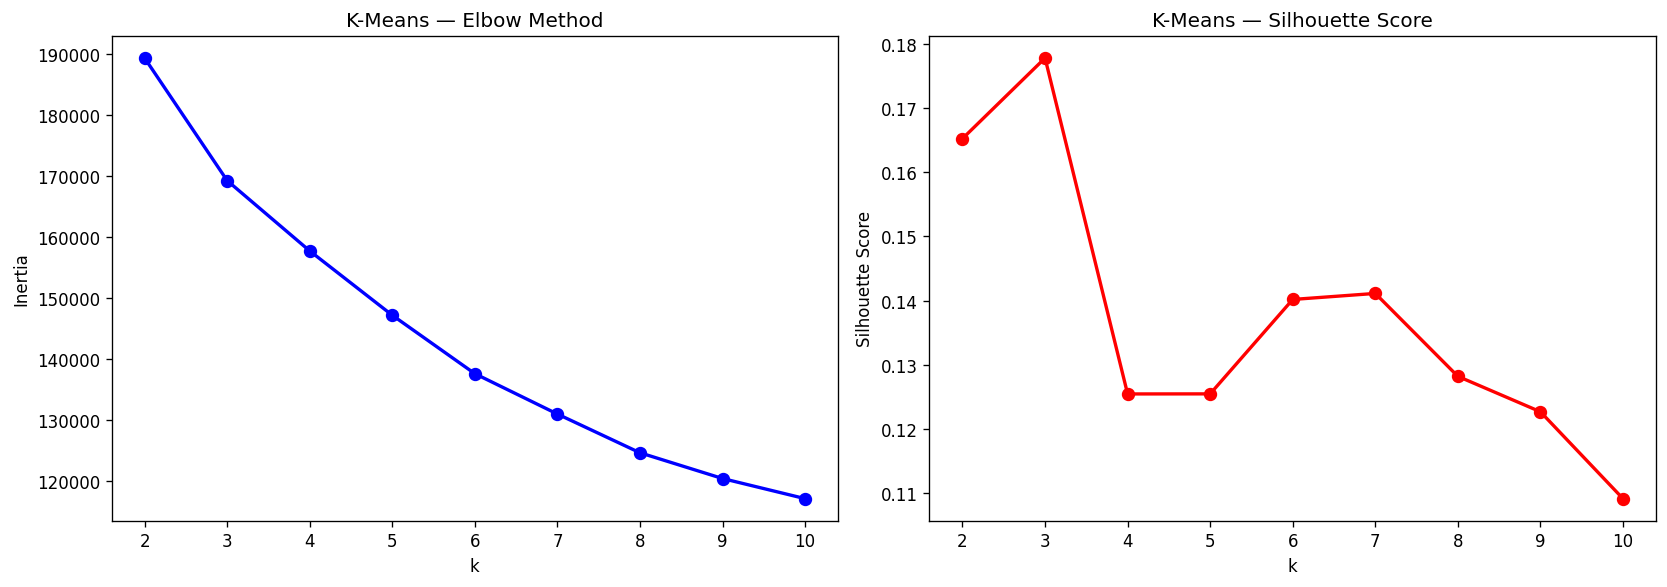


Best k by silhouette: 3


In [15]:
k_range = range(2, 11)
inertias, silhouettes = [], []

print('K-Means k selection on full feature set...')
print(f'{"k":>4} {"Inertia":>12} {"Silhouette":>12}')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_full.values)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_full.values, labels, sample_size=min(2000, len(X_full)), random_state=42)
    silhouettes.append(sil)
    print(f'{k:>4} {km.inertia_:>12.0f} {sil:>12.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('K-Means — Elbow Method')

axes[1].plot(list(k_range), silhouettes, 'ro-', linewidth=2, markersize=7)
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('K-Means — Silhouette Score')

plt.tight_layout()
plt.savefig('figures/kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f'\nBest k by silhouette: {best_k}')

Running K-Means (k=3) on all feature sets...
  Full         sil=0.1777  DB=1.7846  CH=370.6
  PCA-70       sil=0.2686  DB=1.3279  CH=606.3
  PCA-80       sil=0.2277  DB=1.5045  CH=502.4
  Economic     sil=0.2065  DB=1.6030  CH=720.4


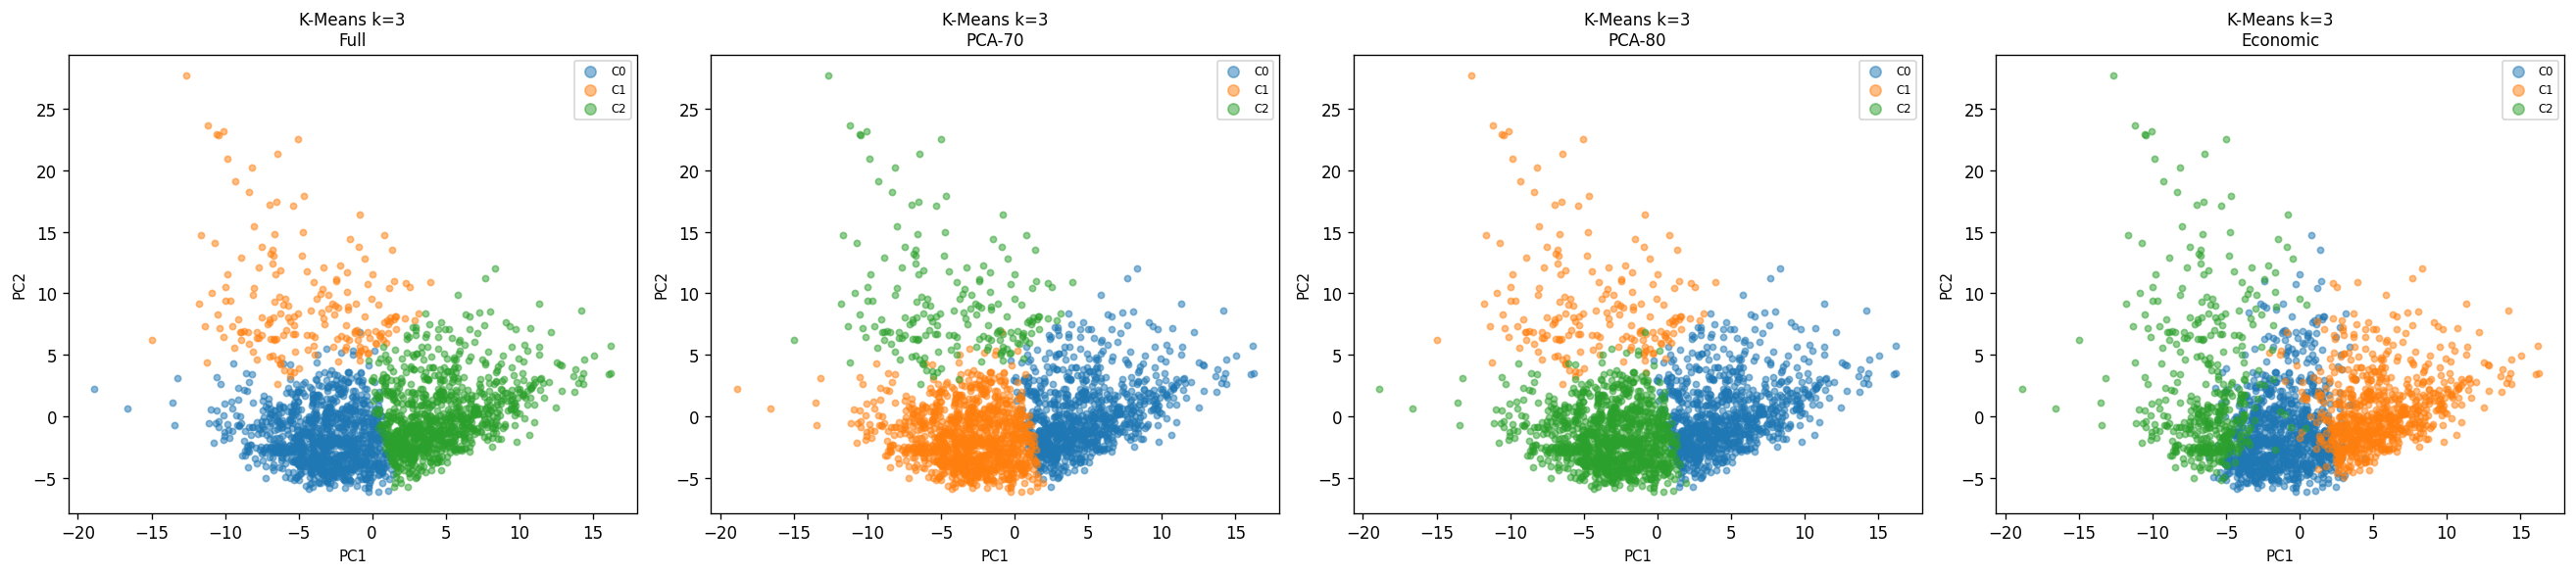

K-Means saved.


In [16]:
print(f'Running K-Means (k={best_k}) on all feature sets...')
kmeans_results = {}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, (name, X) in enumerate(feature_sets.items()):
    km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    m = compute_metrics(X, labels)
    kmeans_results[name] = {'labels': labels, 'metrics': m, 'model': km}
    plot_clusters(X_viz, labels, f'K-Means k={best_k}\n{name}', axes[i])
    print(f'  {name:<12} sil={m["silhouette"]:.4f}  DB={m["davies_bouldin"]:.4f}  CH={m["calinski_harabasz"]:.1f}')

plt.tight_layout()
plt.savefig('figures/kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

all_results['KMeans'] = kmeans_results
joblib.dump(kmeans_results, 'results_kmeans.pkl')
print('K-Means saved.')